In [1]:
import pandas as pd
import bar_chart_race as bcr
from utils.db_connector import get_engine

engine = get_engine()

Konekcija kreirana: localhost/smart_store


In [3]:
# Učitaj podatke za Top 10 States
df_states = pd.read_sql("""
    SELECT 
        c.full_date,
        g.state_or_province,
        SUM(f.sales) as sales
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_geography g ON g.geography_id = f.geography_id
    GROUP BY c.full_date, g.state_or_province
    ORDER BY c.full_date
""", engine)

# Pivot tabela
pivot = df_states.pivot_table(
    index='full_date',
    columns='state_or_province',
    values='sales',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_cumsum = pivot.cumsum()

print(f"✅ Podaci učitani: {pivot_cumsum.shape}")

✅ Podaci učitani: (363, 49)


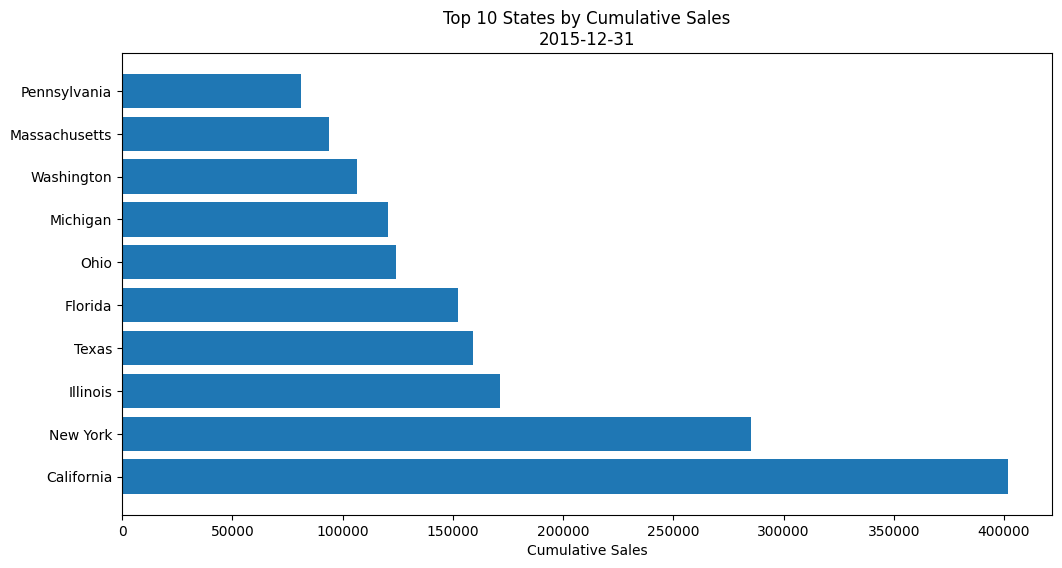

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(12, 6))

def animate(i):
    ax.clear()
    date = pivot_cumsum.index[i]
    data = pivot_cumsum.iloc[i].nlargest(10)
    
    ax.barh(data.index, data.values)
    ax.set_title(f'Top 10 States by Cumulative Sales\n{date}')
    ax.set_xlabel('Cumulative Sales')

ani = animation.FuncAnimation(
    fig, animate, 
    frames=len(pivot_cumsum),
    interval=100
)

ani.save('exports/top10_states_sales.gif', writer='pillow', fps=10)
plt.show()

In [5]:
# Učitaj podatke za Order Priority po sedmici
df_priority = pd.read_sql("""
    SELECT 
        c.week_number,
        c.year,
        o.order_priority,
        SUM(f.profit) as profit
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_orderpriority o ON o.orderpriority_id = f.orderpriority_id
    GROUP BY c.year, c.week_number, o.order_priority
    ORDER BY c.year, c.week_number
""", engine)

# Dodaj year_week kolonu za sortiranje
df_priority['year_week'] = df_priority['year'].astype(str) + '-W' + df_priority['week_number'].astype(str).str.zfill(2)

# Pivot tabela
pivot_priority = df_priority.pivot_table(
    index='year_week',
    columns='order_priority',
    values='profit',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_priority_cumsum = pivot_priority.cumsum()

print(f"✅ Podaci učitani: {pivot_priority_cumsum.shape}")
print(pivot_priority_cumsum.head())

✅ Podaci učitani: (53, 5)
order_priority  Critical     High       Low   Medium  Not Specified
year_week                                                          
2015-W00         -607.47  1343.46  -1453.07  2595.07        -949.11
2015-W01       -12734.46  3142.79  -4558.58  -185.34        -278.93
2015-W02       -11161.46  1533.76  -4583.93  1571.26       -1686.12
2015-W03       -10310.38   764.82   3690.02  4391.42       -1340.11
2015-W04       -18149.67   303.16  14300.97  1883.99        2705.16


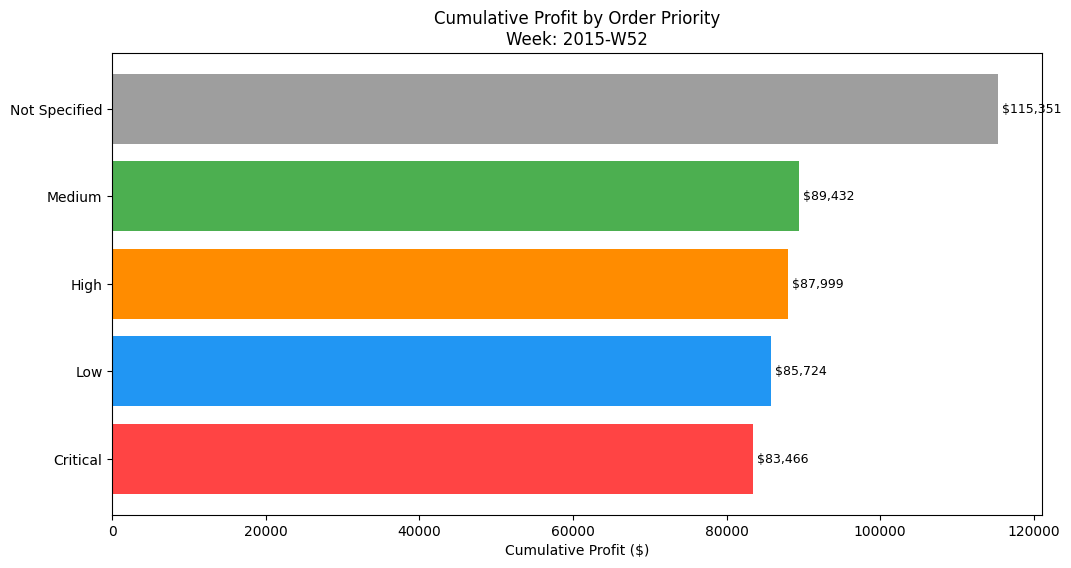

✅ GIF sačuvan!


In [6]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

colors = {
    'Critical': '#FF4444',
    'High': '#FF8C00',
    'Medium': '#4CAF50',
    'Low': '#2196F3',
    'Not Specified': '#9E9E9E'
}

def animate_priority(i):
    ax2.clear()
    week = pivot_priority_cumsum.index[i]
    data = pivot_priority_cumsum.iloc[i].sort_values(ascending=True)
    
    bar_colors = [colors.get(p, '#9E9E9E') for p in data.index]
    
    ax2.barh(data.index, data.values, color=bar_colors)
    ax2.set_title(f'Cumulative Profit by Order Priority\nWeek: {week}')
    ax2.set_xlabel('Cumulative Profit ($)')
    
    for j, val in enumerate(data.values):
        ax2.text(val, j, f' ${val:,.0f}', va='center', fontsize=9)

ani_priority = animation.FuncAnimation(
    fig2, animate_priority,
    frames=len(pivot_priority_cumsum),
    interval=200
)

ani_priority.save('exports/priority_profit_race.gif', writer='pillow', fps=5)
plt.show()
print("✅ GIF sačuvan!")